# Monte-Carlo-Simulation: Eintreffzeiten im Rettungsdienst

### Allgemeiner Hintergrund und Datenbasis
Für die Risikoanalyse des Rettungsdienstes im Bezirk Feldkirch betrachten wir die aggregierten Einsatzdaten eines gesamten Kalenderjahres. Im gesamten Bezirk fanden in diesem Zeitraum insgesamt **12.500 Einsätze** statt, die sich auf drei spezifische Einsatzstichworte verteilen:

* **R8 (6.000 Einsätze):** Einsatz ohne Notarzt und ohne Blaulicht. Es handelt sich um reguläre Krankentransporte oder nicht-akute Fahrten, bei denen Verkehrsregeln normal eingehalten werden.
* **R1 (4.500 Einsätze):** Einsatz ohne Notarzt, aber mit Blaulicht. Ein akuter Notfall, bei dem der Rettungswagen (RTW) Sonderrechte nutzt und schneller vorankommt.
* **R2 (2.000 Einsätze):** Einsatz mit Notarzt und mit Blaulicht. Höchste medizinische Priorität. Der RTW fährt mit Sonderrechten. Zusätzlich fordert die Leitstelle den Notarzt an. 

Der Notarzt befindet sich an einer separaten Wache in 2,8 km Entfernung von der RTW-Station. Bei einer Blaulichtfahrt mit einer Durchschnittsgeschwindigkeit von 60 km/h benötigt das Notarztfahrzeug für diese Strecke rund 168 Sekunden Basis-Anfahrtszeit, die je nach Verkehrslage schwankt.

### Fragestellung
Für das Qualitätsmanagement im Bezirk gilt eine allgemeine Fristvorgabe von 15 Minuten (900 Sekunden) ab dem Alarmierungseingang für alle Einsätze. 

**Hauptfrage:** Wie hoch ist die Wahrscheinlichkeit, dass die Frist von 15 Minuten überschritten wird, wenn wir die reale Verteilung der 12.500 jährlichen Einsätze (R8, R1, R2) in einer Monte-Carlo-Simulation abbilden? Welchen Mittelwert und welche Standardabweichung zeigt das Gesamtsystem?

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Parameter für die Simulation festlegen
anzahl_simulationen = 10000000
frist_sekunden = 15 * 60  # 15 Minuten in Sekunden

# Einsatzzahlen aus dem Jahresdatensatz des Bezirks R_FK
einsaetze_r8 = 6000
einsaetze_r1 = 4500
einsaetze_r2 = 2000
gesamt_einsaetze = einsaetze_r8 + einsaetze_r1 + einsaetze_r2

# Automatische Berechnung der Wahrscheinlichkeiten für die Simulation
p_r8 = einsaetze_r8 / gesamt_einsaetze
p_r1 = einsaetze_r1 / gesamt_einsaetze
p_r2 = einsaetze_r2 / gesamt_einsaetze

stichworte = ['R8', 'R1', 'R2']
wahrscheinlichkeiten = [p_r8, p_r1, p_r2]

# Zufällige Zuweisung der Stichworte für alle Simulationsläufe
simulierte_stichworte = np.random.choice(stichworte, size=anzahl_simulationen, p=wahrscheinlichkeiten)

# Arrays für die Ergebnisse initialisieren
ausrueckzeit = np.zeros(anzahl_simulationen)
fahrtzeit_rtw = np.zeros(anzahl_simulationen)
notarzt_verzoegerung = np.zeros(anzahl_simulationen)

for i in range(anzahl_simulationen):
    typ = simulierte_stichworte[i]
    
    if typ == 'R8':
        ausrueckzeit[i] = np.random.normal(120, 20)
        fahrtzeit_rtw[i] = np.random.gamma(shape=6, scale=90)
        notarzt_verzoegerung[i] = 0
        
    elif typ == 'R1':
        ausrueckzeit[i] = np.random.normal(90, 15)
        fahrtzeit_rtw[i] = np.random.gamma(shape=4, scale=80)
        notarzt_verzoegerung[i] = 0
        
    elif typ == 'R2':
        ausrueckzeit[i] = np.random.normal(85, 10)
        fahrtzeit_rtw[i] = np.random.gamma(shape=4, scale=75)
        notarzt_verzoegerung[i] = np.random.normal(168, 25)

# Gesamtezeit für jeden Simulationslauf berechnen
gesamte_zeit = ausrueckzeit + fahrtzeit_rtw + notarzt_verzoegerung

# Wahrscheinlichkeit für Überschreitung der Frist berechnen
ueberschritten = gesamte_zeit > frist_sekunden
wahrscheinlichkeit_ueberschreitung = np.mean(ueberschritten) * 100

# Statistische Kennzahlen ermitteln
mittelwert_sekunden = np.mean(gesamte_zeit)
standardabweichung_sekunden = np.std(gesamte_zeit)

# Ergebnisse ausgeben
print(f"Ergebnisse aus {anzahl_simulationen} Simulationsläufen für R_FK:")
print(f"Mittelwert der Eintreffzeit: {mittelwert_sekunden / 60:.2f} Minuten ({mittelwert_sekunden:.1f} Sekunden)")
print(f"Standardabweichung: {standardabweichung_sekunden / 60:.2f} Minuten ({standardabweichung_sekunden:.1f} Sekunden)")
print(f"Wahrscheinlichkeit für Überschreitung der Frist (15 Min): {wahrscheinlichkeit_ueberschreitung:.2f}%")

Ergebnisse aus 10000000 Simulationsläufen für R_FK:
Mittelwert der Eintreffzeit: 9.21 Minuten (552.9 Sekunden)
Standardabweichung: 3.70 Minuten (222.2 Sekunden)
Wahrscheinlichkeit für Überschreitung der Frist (15 Min): 7.42%


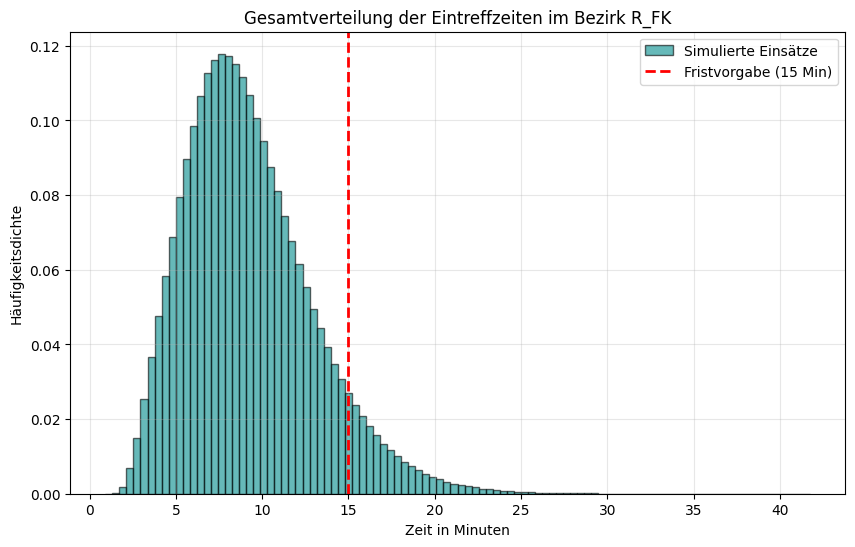

In [ ]:
# Histogramm erstellen
plt.figure(figsize=(10, 6))
plt.hist(gesamte_zeit / 60, bins=100, density=True, alpha=0.6, color='darkcyan', edgecolor='black', label='Simulierte Einsätze')

# 15-Minuten-Frist als rote Linie einzeichnen
plt.axvline(15, color='red', linestyle='--', linewidth=2, label='Fristvorgabe (15 Min)')

# Beschriftungen und Layout
plt.title('Gesamtverteilung der Eintreffzeiten im Bezirk Feldkirch')
plt.xlabel('Zeit in Minuten')
plt.ylabel('Häufigkeitsdichte')
plt.legend()
plt.grid(True, alpha=0.3)

# Grafik anzeigen
plt.show()

### Interpretation der Ergebnisse

* **Mittelwert:** Die simulierte durchschnittliche Eintreffzeit über das gesamte Einsatzspektrum des Bezirks R_FK liegt bei 9,21 Minuten (552,9 Sekunden). Im Durchschnitt wird die Vorgabe damit gut erfüllt.
* **Standardabweichung:** Die Standardabweichung ist mit 3,70 Minuten (222,2 Sekunden) relativ hoch. Das zeigt eine starke Streuung der Einsätze. Ursache hierfür ist die Kombination aus den langsameren R8-Fahrten ohne Sonderrechte und den R2-Einsätzen, bei denen die zusätzliche Anfahrt des 2,8 km entfernten Notarztes das Eintreffen verzögert.
* **Wahrscheinlichkeit:** Die Wahrscheinlichkeit für eine Überschreitung der 15-Minuten-Frist liegt bei 7,42 %. Das bedeutet, dass bei fast jedem 13. Einsatz die Frist nicht eingehalten werden kann. 

### Fazit für das Qualitätsmanagement
Für die Rettungsdienstplanung im Bezirk Feldkirch liefert diese Simulation eine wichtige Erkenntnis. Da die Frist in über 7 % der Fälle überschritten wird, sollte analysiert werden, ob die Stationierung des Notarztes in 2,8 km Entfernung optimiert werden kann oder ob für die zeitintensiven R8-Einsätze separate Transportkapazitäten geschaffen werden müssen, um die Notfallrettung (R1 und R2) zu entlasten.